# Exploration — Attrition des employés

Jeu de données IBM HR Analytics (1470 employés, 35 variables). Objectif : comprendre la distribution de la cible et identifier les variables les plus liées au départ des employés, avant modélisation.

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data import load_raw, DROP_COLUMNS

sns.set_style('darkgrid')
df = load_raw()
df.shape

(1470, 35)

## Aperçu des données

In [2]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Colonnes non informatives

Certaines colonnes n'ont qu'une seule valeur sur l'ensemble du jeu de données : aucune valeur prédictive, elles seront supprimées avant l'entraînement.

In [3]:
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print('Colonnes constantes :', constant_cols)
print('Colonnes supprimées avant modélisation :', DROP_COLUMNS)

Colonnes constantes : ['EmployeeCount', 'Over18', 'StandardHours']
Colonnes supprimées avant modélisation : ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']


## Distribution de la cible

La classe "Attrition = Yes" est minoritaire : c'est un point important pour le choix des métriques d'évaluation (l'accuracy seule serait trompeuse).

Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64


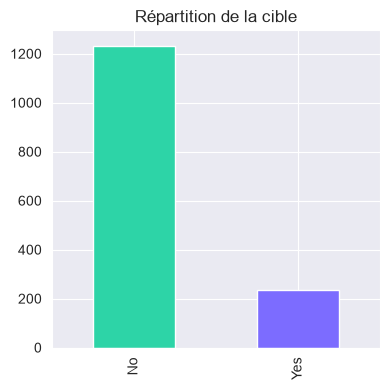

In [4]:
counts = df['Attrition'].value_counts(normalize=True) * 100
print(counts.round(1))

fig, ax = plt.subplots(figsize=(4, 4))
df['Attrition'].value_counts().plot(kind='bar', color=['#2DD4A7', '#7C6CFF'], ax=ax)
ax.set_title('Répartition de la cible')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## Variables numériques les plus corrélées à l'attrition

Encodage binaire de la cible puis corrélation de Pearson avec chaque variable numérique.

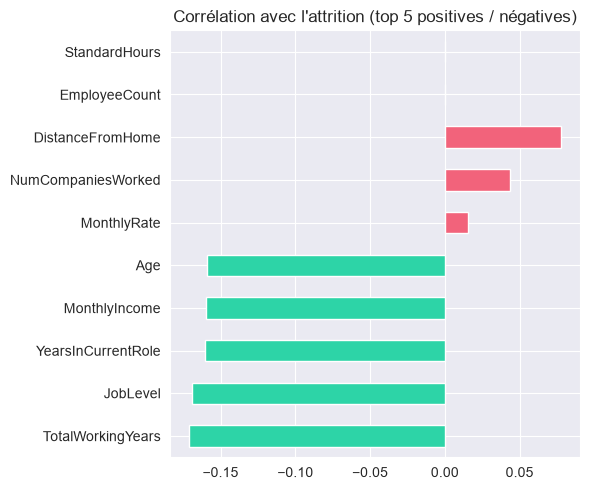

In [5]:
numeric_df = df.select_dtypes('number').copy()
numeric_df['Attrition'] = (df['Attrition'] == 'Yes').astype(int)

corr = numeric_df.corr()['Attrition'].drop('Attrition').sort_values()
top = pd.concat([corr.head(5), corr.tail(5)])

fig, ax = plt.subplots(figsize=(6, 5))
top.plot(kind='barh', color=['#F2637B' if v > 0 else '#2DD4A7' for v in top], ax=ax)
ax.set_title('Corrélation avec l\'attrition (top 5 positives / négatives)')
plt.tight_layout()
plt.show()

## Heures supplémentaires : le facteur le plus visible

Croisement simple entre `OverTime` et `Attrition`.

In [6]:
pd.crosstab(df['OverTime'], df['Attrition'], normalize='index').round(3) * 100

Attrition,No,Yes
OverTime,,
No,89.6,10.4
Yes,69.5,30.5


## Conclusion

- Cible déséquilibrée (~16% d'attrition) : les métriques d'évaluation doivent aller au-delà de l'accuracy (ROC-AUC, précision/rappel sur la classe minoritaire).
- Les heures supplémentaires, la satisfaction au travail et l'ancienneté ressortent comme facteurs importants — cohérent avec la littérature RH.
- Suite : entraînement et évaluation dans `src/train.py` (voir `python -m src.train`).